# Deep learning models for arrhythmia detection and diagnosis

## Initialisation

In [3]:
# Imports
import os
from os.path import join as osj
import pandas as pd
import numpy as np
import torch
import wfdb
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

# Directory where the dataset is stored
dataset_directory = 'mit-bih-arrhythmia-database-1.0.0/'

# Get an array of all ids
record_ids = pd.read_csv('mit-bih-arrhythmia-database-1.0.0/RECORDS', header=None).to_numpy().reshape(-1)

# Initialise dictionaries to store data
lead1 = {}
lead2 = {}
annotations = {}

# Load ECG signals and annotations
for id in record_ids:
    signals, info = wfdb.io.rdsamp(osj(dataset_directory, str(id)))
    annotation = wfdb.rdann(dataset_directory + str(id), "atr")
    lead1[id] = signals[:, 0]
    lead2[id] = signals[:, 1]
    annotations[id] = annotation
            

### Visualisation

Text(0, 0.5, 'Amplitude (mV)')

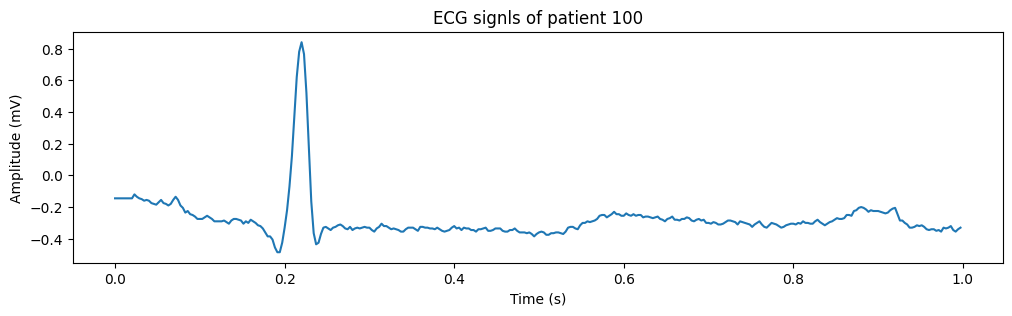

In [2]:
patient_id = 100 # can change
starting_time = 0 # can change
ending_time = 1 # can change

starting_signal_point = starting_time*350
ending_signal_point = ending_time*350 # As sampling frequency is 350 Hz
x = np.arange(starting_time, ending_time, 1/350)
signal = lead1[patient_id][starting_signal_point: ending_signal_point]

plt.figure(figsize=(12, 3), dpi=100)
plt.plot(x, signal)
plt.title(f'ECG signls of patient {patient_id}')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (mV)')

## Data Preprocessing

### Filtering 

In [ ]:
# R-peak ploting
x = np.arange(1, 1081)

n_peak =5
r_peak_x = []
r_peak_y = []
for i in range(0, n_peak):
  r_peak_x.append(Rlocation[i])
  r_peak_y.append(rdata[Rlocation[i]])

plt.plot(x, data[0:1080], color='red')
plt.scatter(r_peak_x, r_peak_y)

### Segmentation

### Normalisation

## Models

### Beat Classifier

In [ ]:
class BeatClassifier(nn.Module):
    def __init__(self, input_size, num_classes):
        super(BeatClassifier, self).__init__()
        
        # Feature extraction layers
        self.feature_extractor = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=64, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),
            nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )
        
        # Fully connected layers for classification
        self.classifier = nn.Sequential(
            nn.Linear(128 * (input_size // 4), 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        x = self.feature_extractor(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.classifier(x)
        return x

### Signal Classifier

In [ ]:
class SignalClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(SignalClassifier, self).__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x, _ = self.lstm(x)
        x = x[:, -1, :]  # Take the last time step output
        x = self.dropout(x)
        x = self.fc(x)
        return x
    
class SignalTransformer(nn.Module):
    def __init__(self, input_size=3, d_model=64, num_heads=4, num_layers=2, num_classes=5):
        super(SignalTransformer, self).__init__()
        
        # Positional Encoding
        self.positional_encoding = nn.Parameter(torch.zeros(1, 100, d_model))  # Max sequence length = 100
        
        # Transformer Encoder Layer
        self.encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=num_heads)
        self.transformer = nn.TransformerEncoder(self.encoder_layer, num_layers=num_layers)
        
        # Fully Connected Layer
        self.fc = nn.Linear(d_model, num_classes)
        self.softmax = nn.Softmax(dim=1)
        
    def forward(self, x):
        # x: Batch size x sequence length x input size
        x = x * np.sqrt(64)  # Scaling input (similar to Transformer)
        
        # Add positional encoding (optional)
        x = x + self.positional_encoding[:, :x.size(1), :]
        
        # Transformer expects input shape (seq_len, batch_size, input_size)
        x = x.permute(1, 0, 2)  # Shape: (sequence_length, batch_size, feature_size)
        
        # Pass through Transformer Encoder
        x = self.transformer(x)
        
        # Use the output of the last token
        x = x[-1, :, :]  # Only take the last token's output
        
        # Final classification
        x = self.fc(x)
        x = self.softmax(x)
        return x

### Transformer

## Training

In [ ]:
def train_model(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss, correct = 0, 0
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        correct += (predicted == labels).sum().item()
    return total_loss / len(dataloader), correct / len(dataloader.dataset)

## Testing

In [ ]:
def evaluate_model(model, dataloader, device):
    model.eval()
    correct = 0
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            correct += (predicted == labels).sum().item()
    return correct / len(dataloader.dataset)

## Evaluation